First 5 records:
          Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0   
4  10/03/2004  22.00.00    1,6       1272.0      51.0      6,5          836.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   
3    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0   
4    131.0        1205.0    116.0        1490.0       1110.0  11,2  59,6   

       AH  Unnamed: 15  Unnamed: 16  


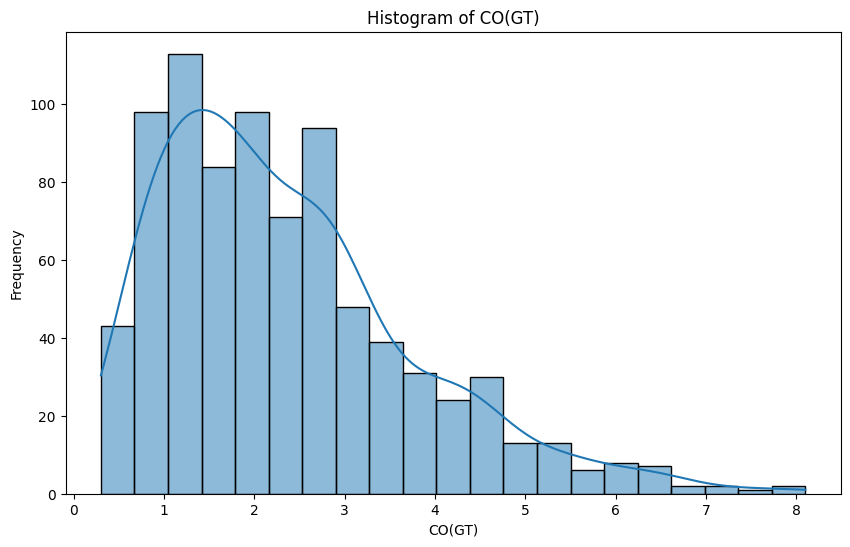

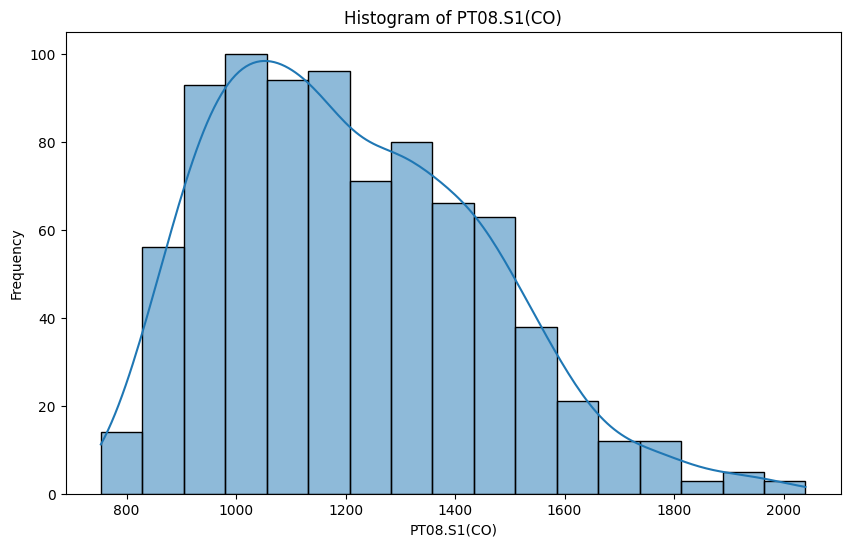

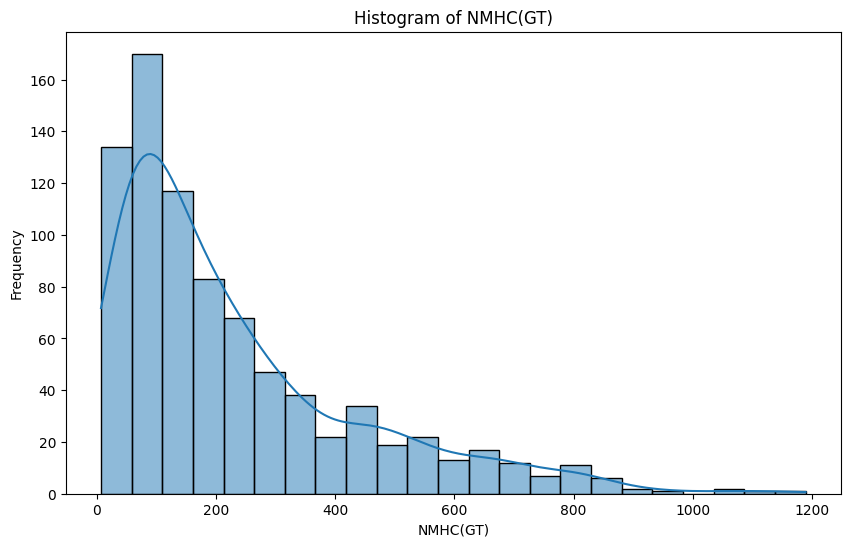

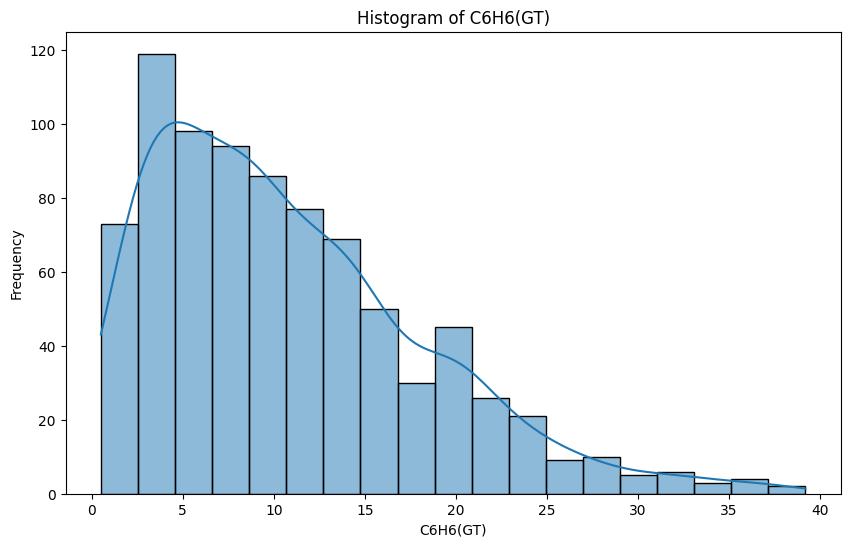

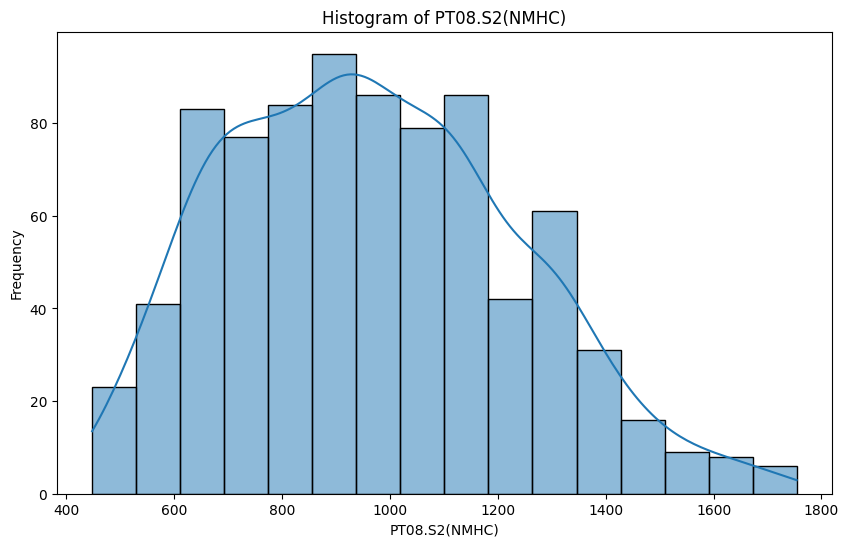

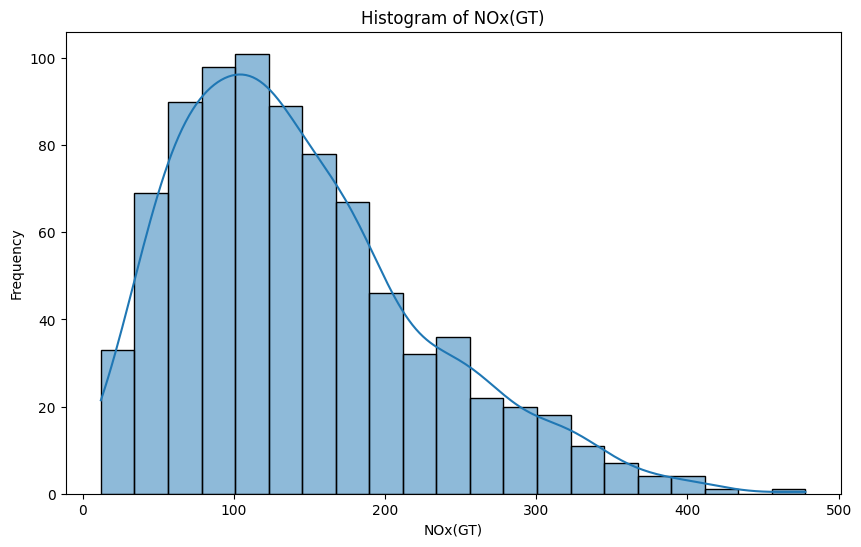

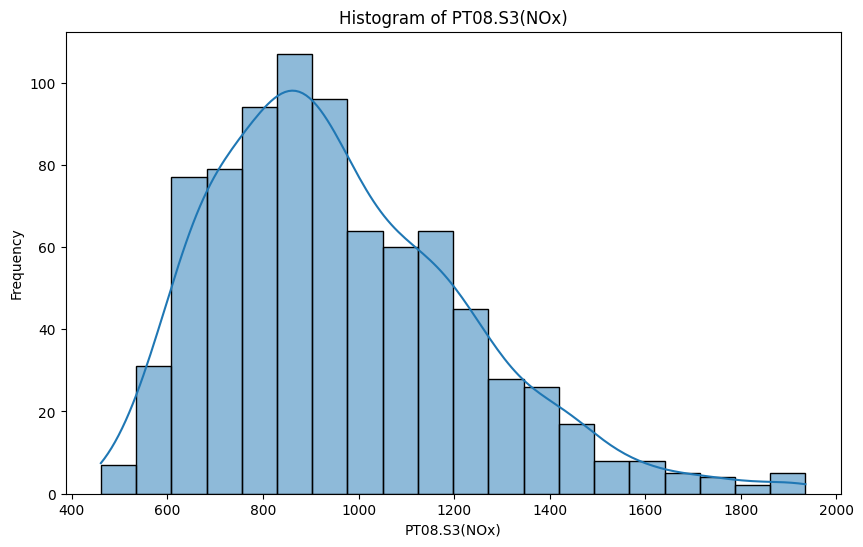

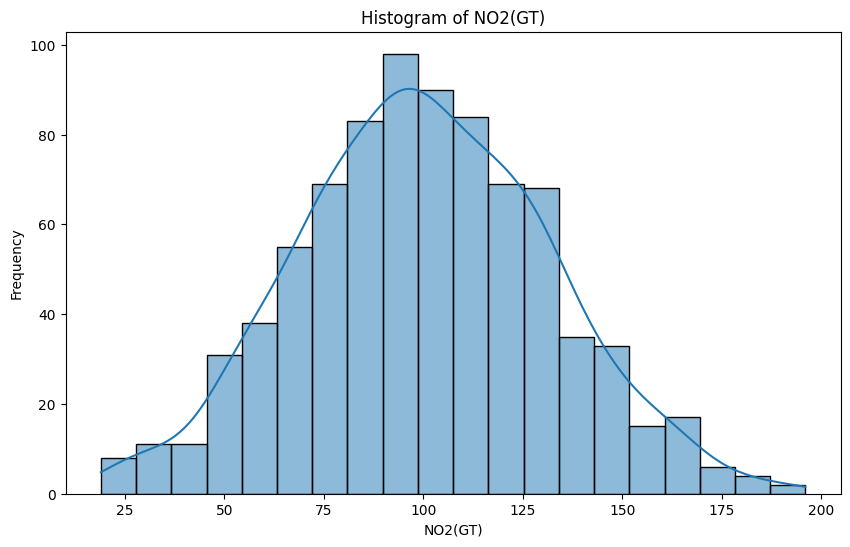

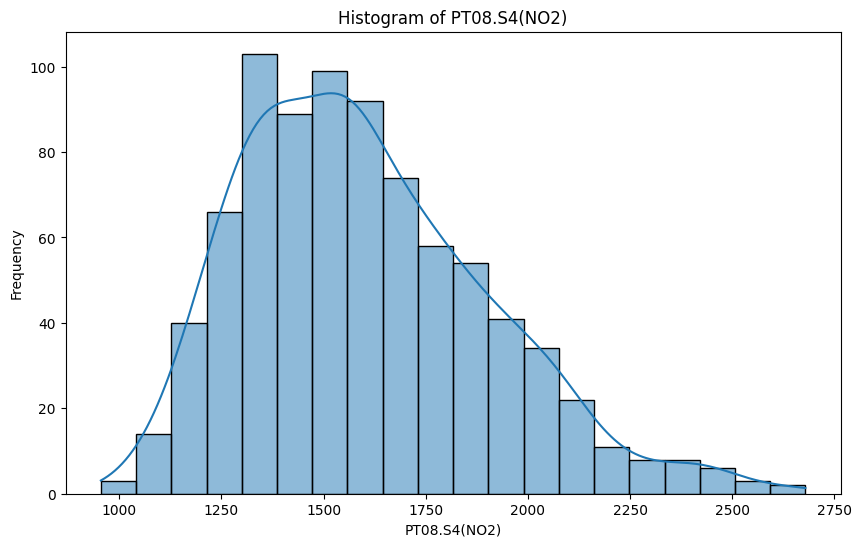

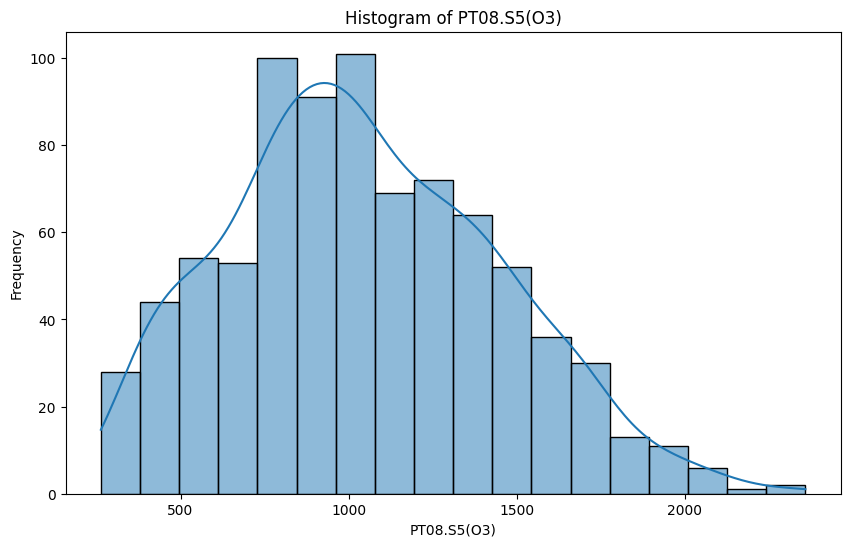

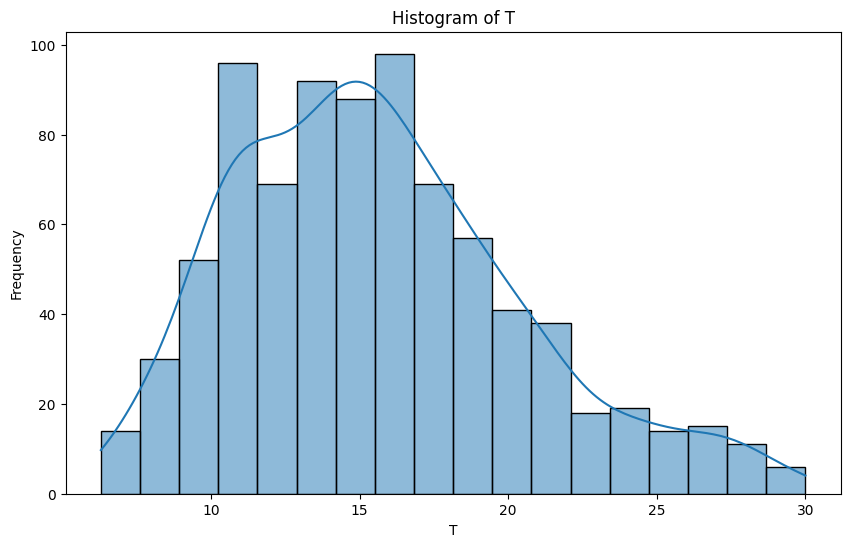

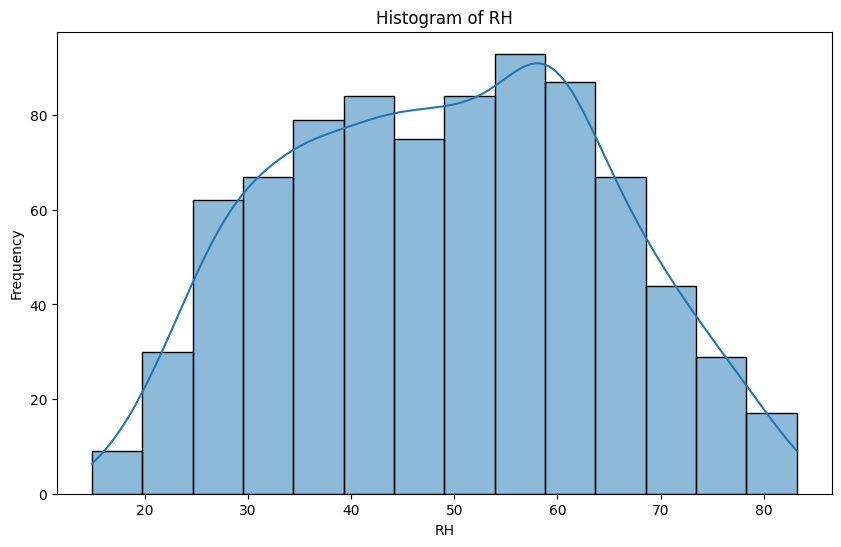

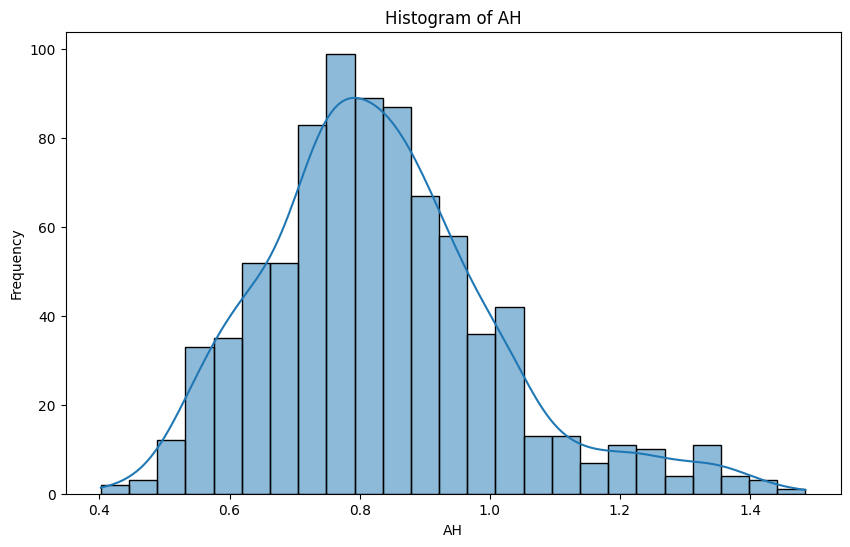

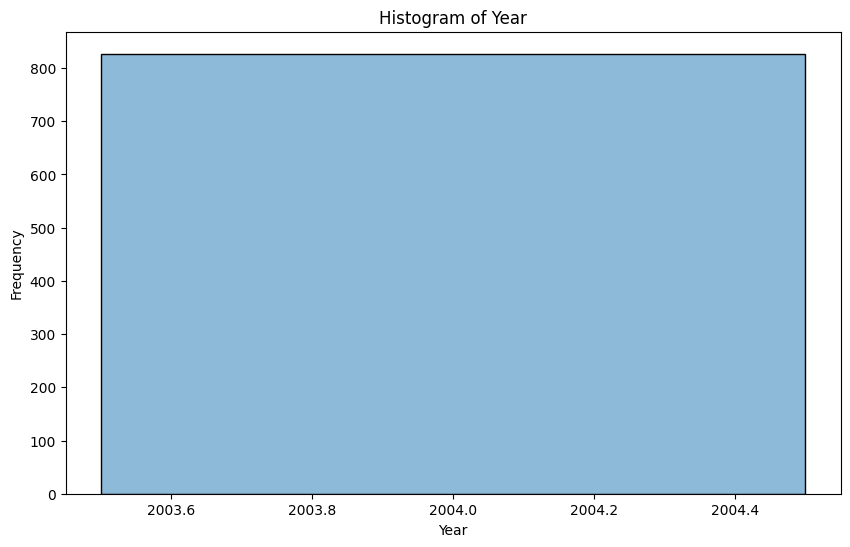

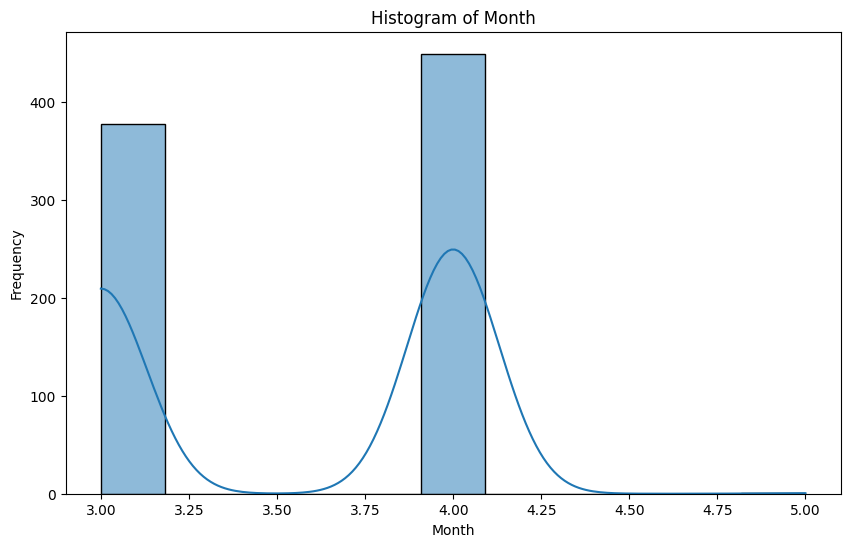

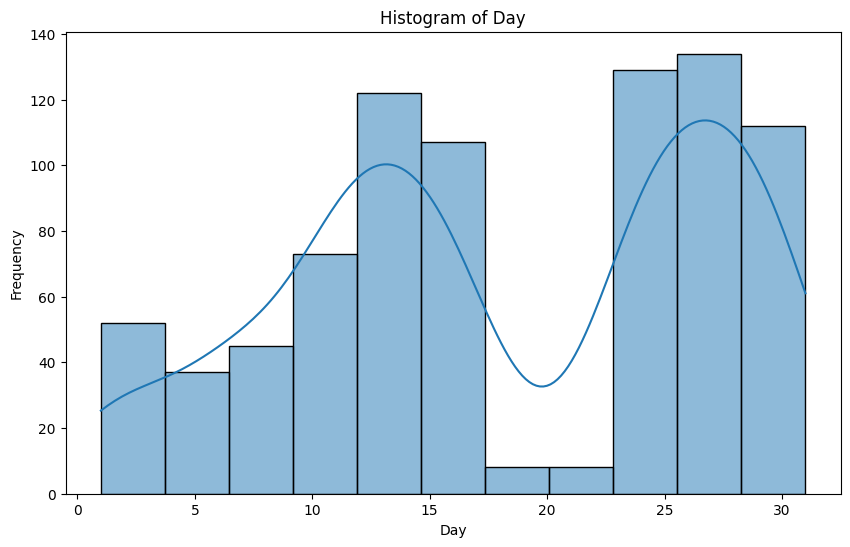

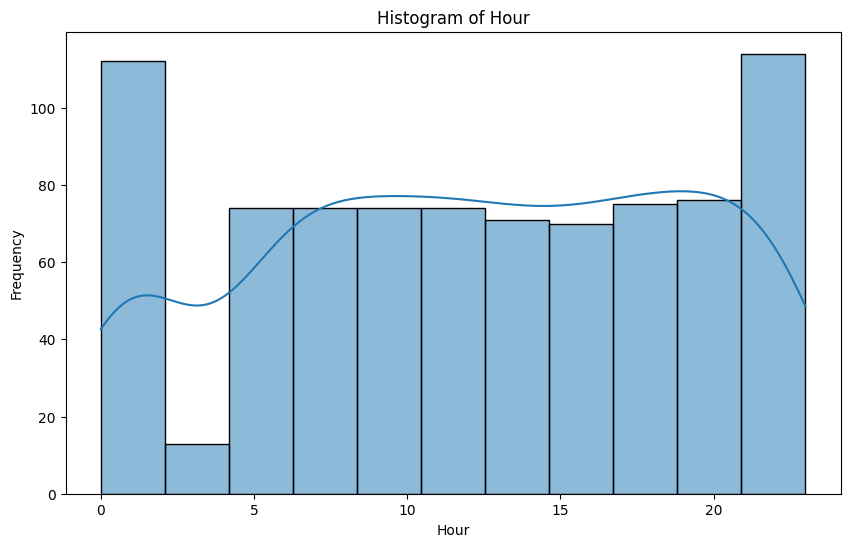

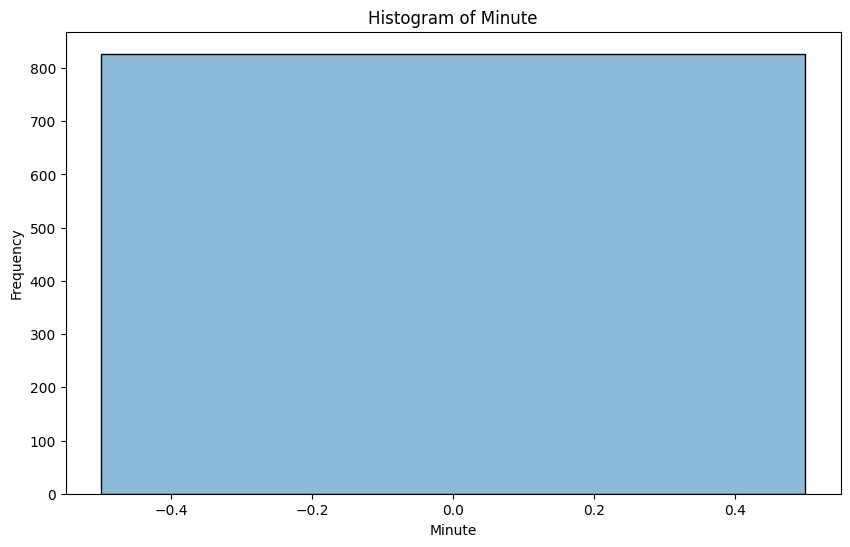

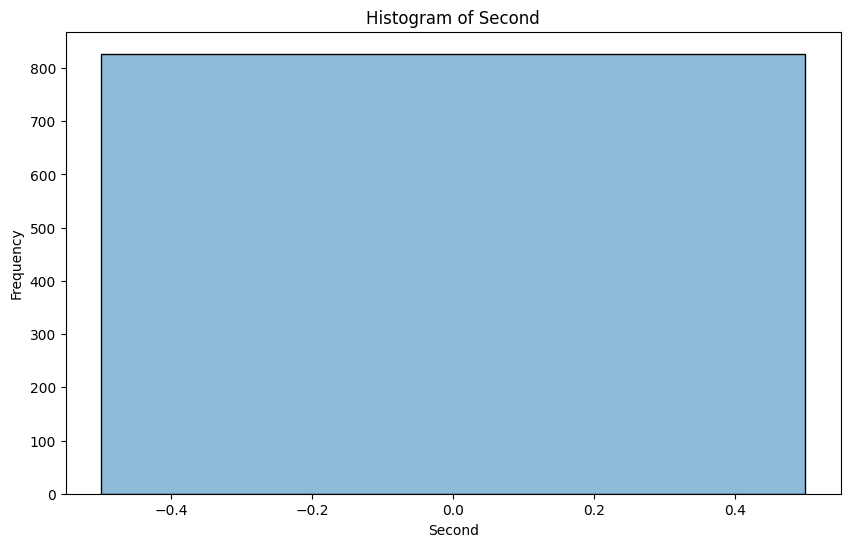


Final cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 0 to 1230
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         827 non-null    float32
 1   PT08.S1(CO)    827 non-null    float64
 2   NMHC(GT)       827 non-null    float64
 3   C6H6(GT)       827 non-null    float32
 4   PT08.S2(NMHC)  827 non-null    float64
 5   NOx(GT)        827 non-null    float64
 6   PT08.S3(NOx)   827 non-null    float64
 7   NO2(GT)        827 non-null    float64
 8   PT08.S4(NO2)   827 non-null    float64
 9   PT08.S5(O3)    827 non-null    float64
 10  T              827 non-null    float32
 11  RH             827 non-null    float32
 12  AH             827 non-null    float32
 13  Year           827 non-null    int32  
 14  Month          827 non-null    int32  
 15  Day            827 non-null    int32  
 16  Hour           827 non-null    int32  
 17  Minute         827 non-null

In [5]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Download latest version
path = kagglehub.dataset_download("fedesoriano/air-quality-data-set")

# Set the path to the file you'd like to load
file_path = f"{path}/AirQuality.csv"

# Load the CSV with the correct encoding
df = pd.read_csv(file_path, encoding='utf-8', delimiter=';')

print("First 5 records:\n", df.head())

print("\nEDA Summary:")
print(df.describe())

print("\nMissing values per column:\n", df.isnull().sum())

print("\nData types:\n", df.dtypes)

print("\nDeleting last two columns...")
df = df.iloc[:, :-2]

print("\nDataFrame shape after deletion:", df.shape)

print("\nColumn names:", df.columns.tolist())

print("\nDeleting rows with any missing values...")
df = df.dropna()

print("\nDataFrame shape after deleting rows with missing values:", df.shape)

print("\nDeleting duplicate rows...")
df = df.drop_duplicates()

print("\nDataFrame shape after deleting duplicate rows:", df.shape)

print("\nConverting 'CO(GT)', 'T', 'RH', 'C6H6(GT)' and 'AH' column to numeric...")
for col in ['CO(GT)', 'T', 'RH', 'C6H6(GT)', 'AH']:
    # Replace comma with dot for decimal conversion
    df[col] = df[col].str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce', downcast='float')
    
print("\nData types after conversion:\n", df.dtypes)

print("\nConverting 'Date' + 'Time' columns to 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'...")
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['Minute'] = df['DateTime'].dt.minute
df['Second'] = df['DateTime'].dt.second
df = df.drop(columns=['Date', 'Time', 'DateTime'])

print("\nDataFrame shape after datetime conversion:", df.shape)

print("\nDeleting outliers. Values less than 0...")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    df = df[df[col] >= 0]
    
print("\nPlotting hist plots for numeric columns...")
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

print("\nFinal cleaned DataFrame info:")
print(df.info())

print("\nFirst 5 records of cleaned DataFrame:\n", df.head())

print("\nData cleaning completed.")

print("\nMatrix of correlations:\n", df.corr())


print("\nPreparing data for modeling...")

print("\nScaling features using Min-Max Scaling...")
scaler = MinMaxScaler()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nScaled DataFrame head:\n", df.head())


print("\nVariable objetive: 'NO2(GT)'")
X = df[['CO(GT)', 'C6H6(GT)', 'NOx(GT)']]
y = df['NO2(GT)']

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

print("\nSplitting data into training and testing sets (70% train, 30% test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nTraining features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)